In [1]:
# Import the libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
# Load the data
df = pd.read_csv('../data/life_expectancy_data_cleaned.csv')

# The first 5 rows
df.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
0,Afghanistan,2000,0,54.8,321.0,88,0.01,10.424960,62.0,6532,...,24.0,8.20,24.0,0.1,114.560000,293756.0,2.3,2.5,0.338,5.5
1,Afghanistan,2001,0,55.3,316.0,88,0.01,10.574728,63.0,8762,...,35.0,7.80,33.0,0.1,117.496980,2966463.0,2.1,2.4,0.340,5.9
2,Afghanistan,2002,0,56.2,3.0,88,0.01,16.887351,64.0,2486,...,36.0,7.76,36.0,0.1,187.845950,21979923.0,19.9,2.2,0.341,6.2
3,Afghanistan,2003,0,56.7,295.0,87,0.01,11.089053,65.0,798,...,41.0,8.82,41.0,0.1,198.728544,2364851.0,19.7,19.9,0.373,6.5
4,Afghanistan,2004,0,57.0,293.0,87,0.02,15.296066,67.0,466,...,5.0,8.79,5.0,0.1,219.141353,24118979.0,19.5,19.7,0.381,6.8


In [3]:
# Create new features
df_fe = df.copy()

# 1. Interaction terms
df_fe['schooling_income_inter'] = df_fe['schooling'] * df_fe['income_composition_of_resources']
df_fe['mortality_hiv_inter'] = df_fe['adult_mortality'] * df_fe['hiv/aids']

# 2. Squared terms (to capture non-linear effects)
df_fe['schooling_sq'] = df_fe['schooling'] ** 2
df_fe['income_comp_sq'] = df_fe['income_composition_of_resources'] ** 2
df_fe['bmi_sq'] = df_fe['bmi'] ** 2
df_fe['adult_mortality_sq'] = df_fe['adult_mortality'] ** 2

# 3. Log transformations (add 1 to avoid log(0) issues)
df_fe['log_adult_mortality'] = np.log(df_fe['adult_mortality'] + 1)
df_fe['log_hiv_aids'] = np.log(df_fe['hiv/aids'] + 1)

# 4. Ratio feature (health burden relative to body mass)
df_fe['mortality_per_bmi'] = df_fe['adult_mortality'] / (df_fe['bmi'] + 1)  # +1 to avoid division by zero

# Check the new columns
new_features = ['schooling_income_inter', 'mortality_hiv_inter', 'schooling_sq',
                'income_comp_sq', 'bmi_sq', 'adult_mortality_sq',
                'log_adult_mortality', 'log_hiv_aids', 'mortality_per_bmi']

df_fe[new_features].head()

,schooling_income_inter,mortality_hiv_inter,schooling_sq,income_comp_sq,bmi_sq,adult_mortality_sq,log_adult_mortality,log_hiv_aids,mortality_per_bmi
0,1.8590,32.1,30.25,0.114244,148.84,103041.0,5.774552,0.09531,24.318182
1,2.0060,31.6,34.81,0.115600,158.76,99856.0,5.758902,0.09531,23.235294
2,2.1142,0.3,38.44,0.116281,169.00,9.0,1.386294,0.09531,0.214286
3,2.4245,29.5,42.25,0.139129,179.56,87025.0,5.690359,0.09531,20.486111
4,2.5908,29.3,46.24,0.145161,190.44,85849.0,5.683580,0.09531,19.797297


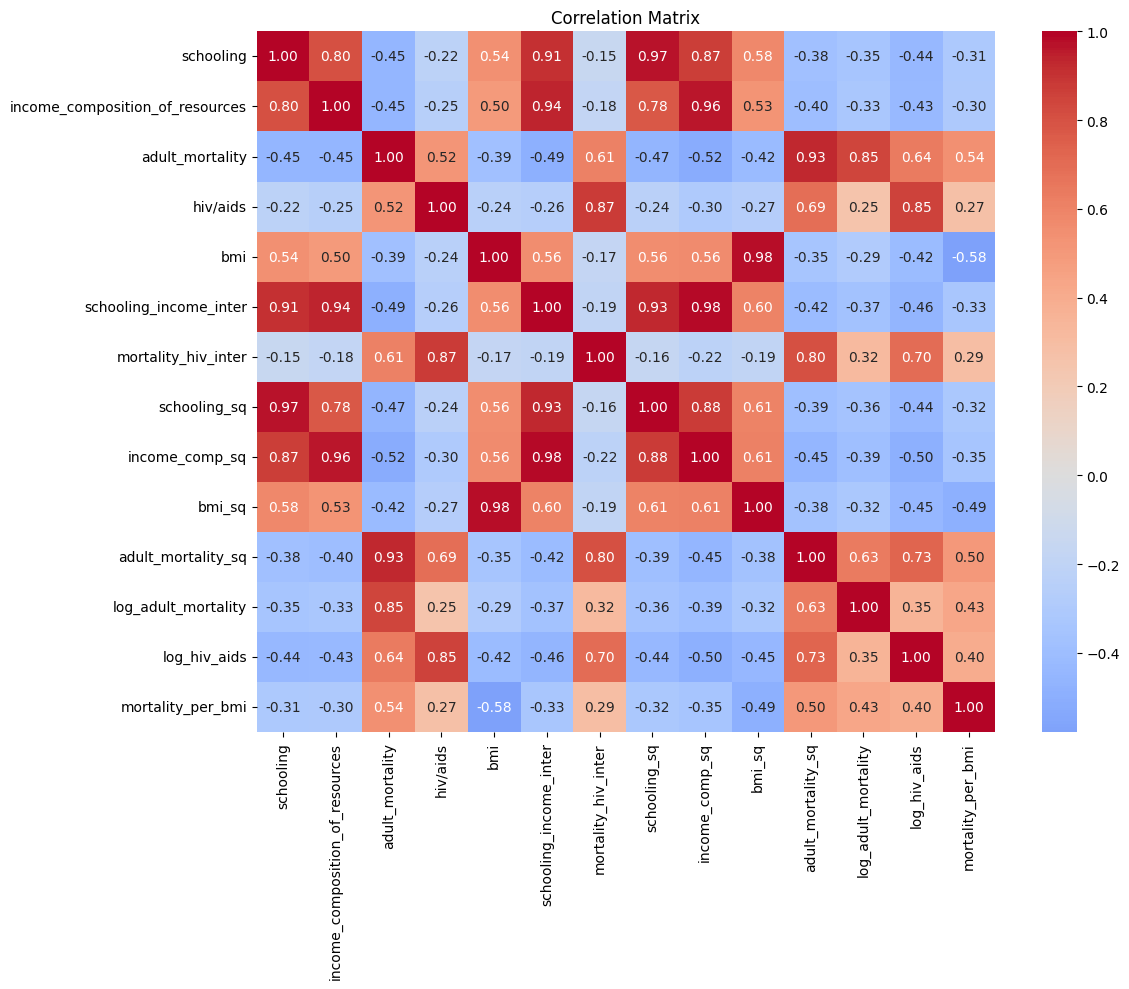

In [4]:
# List of all predictors 
original_key = ['schooling', 'income_composition_of_resources', 'adult_mortality', 'hiv/aids', 'bmi']

new_features = ['schooling_income_inter', 'mortality_hiv_inter', 'schooling_sq',
                'income_comp_sq', 'bmi_sq', 'adult_mortality_sq', 'log_adult_mortality',
                'log_hiv_aids', 'mortality_per_bmi']

all_predictors = original_key + new_features

# Correlation matrix
corr_matrix = df_fe[all_predictors].corr()

# Plot the heatmap
plt.figure(figsize = (12, 10))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [5]:
# VIF 
X = df_fe[all_predictors]
X['intercept'] = 1

vif_data = pd.DataFrame({
    'features': all_predictors,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(len(all_predictors))]
})

print(vif_data)

                           features         VIF
0                         schooling   44.455779
1   income_composition_of_resources   54.606270
2                   adult_mortality   62.428737
3                          hiv/aids   11.358229
4                               bmi   37.373282
5            schooling_income_inter  216.747645
6               mortality_hiv_inter   11.538114
7                      schooling_sq  132.089647
8                    income_comp_sq   54.087259
9                            bmi_sq   35.703226
10               adult_mortality_sq   45.135919
11              log_adult_mortality   10.689944
12                     log_hiv_aids    7.263656
13                mortality_per_bmi    2.736363


As shown above, we have a very high VIF score, so we are going to check the correlation with target to decide which ones to keep.

In [6]:
# Check the correlation of all features with life expectancy
target_corr = {}
for col in all_predictors:
    corr = df_fe['life_expectancy'].corr(df_fe[col])
    target_corr[col] = abs(corr)

# Sort by absolute correlation
sorted_corr = sorted(target_corr.items(), key = lambda x: x[1], reverse = True)
for feat, corr in sorted_corr:
    print(f'{feat:35s} | correlation = {corr:.4f}')

income_comp_sq                      | correlation = 0.7960
schooling_income_inter              | correlation = 0.7679
log_hiv_aids                        | correlation = 0.7663
schooling_sq                        | correlation = 0.7483
schooling                           | correlation = 0.7352
income_composition_of_resources     | correlation = 0.7031
adult_mortality                     | correlation = 0.6964
adult_mortality_sq                  | correlation = 0.6947
bmi_sq                              | correlation = 0.5993
bmi                                 | correlation = 0.5643
hiv/aids                            | correlation = 0.5566
log_adult_mortality                 | correlation = 0.4571
mortality_per_bmi                   | correlation = 0.4479
mortality_hiv_inter                 | correlation = 0.4431


We choose the most correlated features that also do not have a correlation with each other.

In [7]:
# Create the best feature and check VIF again
candidate_features = ['income_comp_sq',
                      'log_hiv_aids', 'schooling_sq', 'adult_mortality', 'bmi_sq', 
                      'mortality_per_bmi', 'mortality_hiv_inter']

In [8]:
X_candidate = df_fe[candidate_features]
X_candidate['intercept'] = 1

vif_candidate = pd.DataFrame({
    'Feature': candidate_features,
    'VIF': [variance_inflation_factor(X_candidate.values, i) for i in range(len(candidate_features))]
})
print("VIF for candidate set:\n", vif_candidate)

VIF for candidate set:
                Feature       VIF
0       income_comp_sq  4.825546
1         log_hiv_aids  2.752757
2         schooling_sq  4.506972
3      adult_mortality  2.579485
4               bmi_sq  1.972667
5    mortality_per_bmi  1.637025
6  mortality_hiv_inter  2.489024


All scores lay below 5 which is promising.

In [9]:
# Adding status column as our already hot encoded categorical column and also life expectancy
final_features = ['income_comp_sq',
                    'log_hiv_aids', 'schooling_sq', 'adult_mortality', 'bmi_sq', 
                    'mortality_per_bmi', 'mortality_hiv_inter', 'status', 'life_expectancy']

In [10]:
# Create the final df 
df_final = df_fe[final_features]
df_final.head()

,income_comp_sq,log_hiv_aids,schooling_sq,adult_mortality,bmi_sq,mortality_per_bmi,mortality_hiv_inter,status,life_expectancy
0,0.114244,0.09531,30.25,321.0,148.84,24.318182,32.1,0,54.8
1,0.115600,0.09531,34.81,316.0,158.76,23.235294,31.6,0,55.3
2,0.116281,0.09531,38.44,3.0,169.00,0.214286,0.3,0,56.2
3,0.139129,0.09531,42.25,295.0,179.56,20.486111,29.5,0,56.7
4,0.145161,0.09531,46.24,293.0,190.44,19.797297,29.3,0,57.0


In [11]:
# Scale the candidate features
scaler = StandardScaler()

df_final[candidate_features] = scaler.fit_transform(df_final[candidate_features])

df_final.head()

,income_comp_sq,log_hiv_aids,schooling_sq,adult_mortality,bmi_sq,mortality_per_bmi,mortality_hiv_inter,status,life_expectancy
0,-1.483151,-0.543192,-1.672243,1.256960,-1.165764,1.093530,-0.230435,0,54.8
1,-1.477007,-0.543192,-1.611430,1.216726,-1.158980,1.018874,-0.230631,0,55.3
2,-1.473922,-0.543192,-1.563020,-1.301966,-1.151977,-0.568216,-0.242920,0,56.2
3,-1.370411,-0.543192,-1.512209,1.047740,-1.144755,0.829343,-0.231456,0,56.7
4,-1.343083,-0.543192,-1.458998,1.031646,-1.137315,0.781856,-0.231534,0,57.0


In [12]:
# Save the scaler for the web app
# Commented to avoid repetitions
#joblib.dump(scaler, '../src/scaler.joblib')
# Save final df to do modeling
#df_final.to_csv('../data/life_expectancy_data_processed.csv')